In [ ]:
from typing import List, Tuple, Dict, Union, Optional, Any, Set, Callable

## Prefix Sum

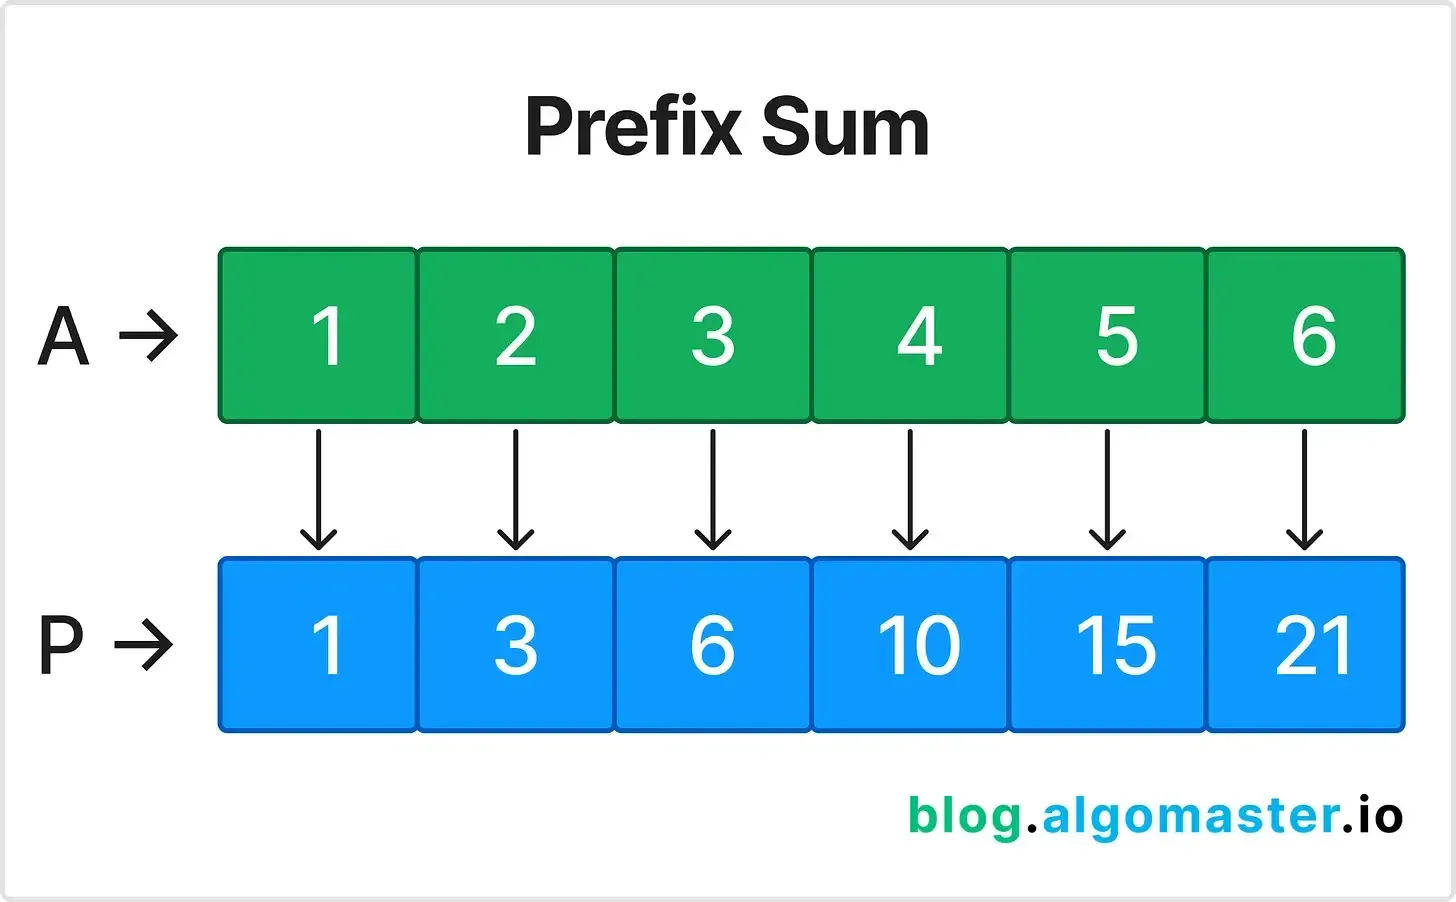

Prefix Sum involves preprocessing an array to create a new array where each element at index i represents the sum of the array from the start up to i. This allows for efficient sum queries on subarrays.

Use this pattern when you need to perform multiple sum queries on a subarray or need to calculate cumulative sums.

Q. Given an integer array nums, handle multiple queries of the following type:

Calculate the sum of the elements of nums between indices left and right inclusive where left <= right.
Implement the NumArray class:

NumArray(int[] nums) Initializes the object with the integer array nums.
int sumRange(int left, int right) Returns the sum of the elements of nums between indices left and right inclusive (i.e. nums[left] + nums[left + 1] + ... + nums[right]).

Example 1:

Input
["NumArray", "sumRange", "sumRange", "sumRange"]
[[[-2, 0, 3, -5, 2, -1]], [0, 2], [2, 5], [0, 5]]
Output
[null, 1, -1, -3]

Explanation
NumArray numArray = new NumArray([-2, 0, 3, -5, 2, -1]);
numArray.sumRange(0, 2); // return (-2) + 0 + 3 = 1
numArray.sumRange(2, 5); // return 3 + (-5) + 2 + (-1) = -1
numArray.sumRange(0, 5); // return (-2) + 0 + 3 + (-5) + 2 + (-1) = -3
 

Constraints:

1 <= nums.length <= 104
-105 <= nums[i] <= 105
0 <= left <= right < nums.length
At most 104 calls will be made to sumRange.

https://leetcode.com/problems/range-sum-query-immutable/

In [ ]:
class NumArray:

    def __init__(self, nums: list[int]):
        self.arr = nums
        self.cum_sum_arr = []
        # cum_sum = 0
        # for num in nums:
        #     cum_sum += num
        #     self.cum_sum_arr.append(cum_sum)
        #     print(self.cum_sum_arr)
        self.cum_sum_arr = [sum(nums[: i+1]) for i in range(len(nums))]

    def sumRange(self, left: int, right: int) -> int:
        # right = min(len(self.cum_sum_arr) -1, right)
        if left == 0:
            # print(f"{left=}, {right=}, {self.cum_sum_arr[right]}")
            return self.cum_sum_arr[right]

        # print(f"{left=}, {right=}, {self.cum_sum_arr[right] - self.cum_sum_arr[left]}")
        return self.cum_sum_arr[right] - self.cum_sum_arr[left - 1]


# Your NumArray object will be instantiated and called as such:
# obj = NumArray(nums)
# param_1 = obj.sumRange(left,right)

Q. Given a binary array nums, return the maximum length of a contiguous subarray with an equal number of 0 and 1.

Example 1:

Input: nums = [0,1]
Output: 2
Explanation: [0, 1] is the longest contiguous subarray with an equal number of 0 and 1.
Example 2:

Input: nums = [0,1,0]
Output: 2
Explanation: [0, 1] (or [1, 0]) is a longest contiguous subarray with equal number of 0 and 1.
Example 3:

Input: nums = [0,1,1,1,1,1,0,0,0]
Output: 6
Explanation: [1,1,1,0,0,0] is the longest contiguous subarray with equal number of 0 and 1.
 

https://leetcode.com/problems/contiguous-array/

In [ ]:
class Solution:
    def findMaxLength(self, nums: list[int]) -> int:
        first_idx_map = {}  # the 1st index of a particular sum occurs
        max_len = 0
        cum_sum = 0
        for i, el in enumerate(nums):
            cum_sum += -1 if el == 0 else 1
            if cum_sum not in first_idx_map:
                first_idx_map[cum_sum] = i

            if cum_sum == 0:
                max_len = max(max_len, i + 1)
            elif cum_sum in first_idx_map:
                max_len = max(max_len, i - first_idx_map[cum_sum])
            
        return max_len
            
        

Q. Given an array of integers nums and an integer k, return the total number of subarrays whose sum equals to k.

A subarray is a contiguous non-empty sequence of elements within an array.

 

Example 1:

Input: nums = [1,1,1], k = 2
Output: 2
Example 2:

Input: nums = [1,2,3], k = 3
Output: 2
 

Constraints:

1 <= nums.length <= 2 * 104
-1000 <= nums[i] <= 1000
-107 <= k <= 107

https://leetcode.com/problems/contiguous-array/description/

In [ ]:
class Solution:
    # O(n^2) solution
    def subarraySumOsq(self, nums: list[int], k: int) -> int:
        count = 0
        for i in range(len(nums)):
            cum_sum = 0
            for j, el in enumerate(nums[i:]):
                cum_sum += el

                if cum_sum == k:
                    count += 1
                
        return count

    # O(n) solution
    def subarraySum(self, nums: list[int], k: int) -> int:
        cum_sum = 0
        count = 0
        cum_sum_counts = {0: 1}

        for i, num in enumerate(nums):
            cum_sum += num

            init_cum_sum = cum_sum  - k
            if init_cum_sum in cum_sum_counts:
                count += cum_sum_counts[init_cum_sum]

            cum_sum_counts[cum_sum] = cum_sum_counts.get(cum_sum, 0) + 1
        
        return count

            
        return count

## Two Pointers

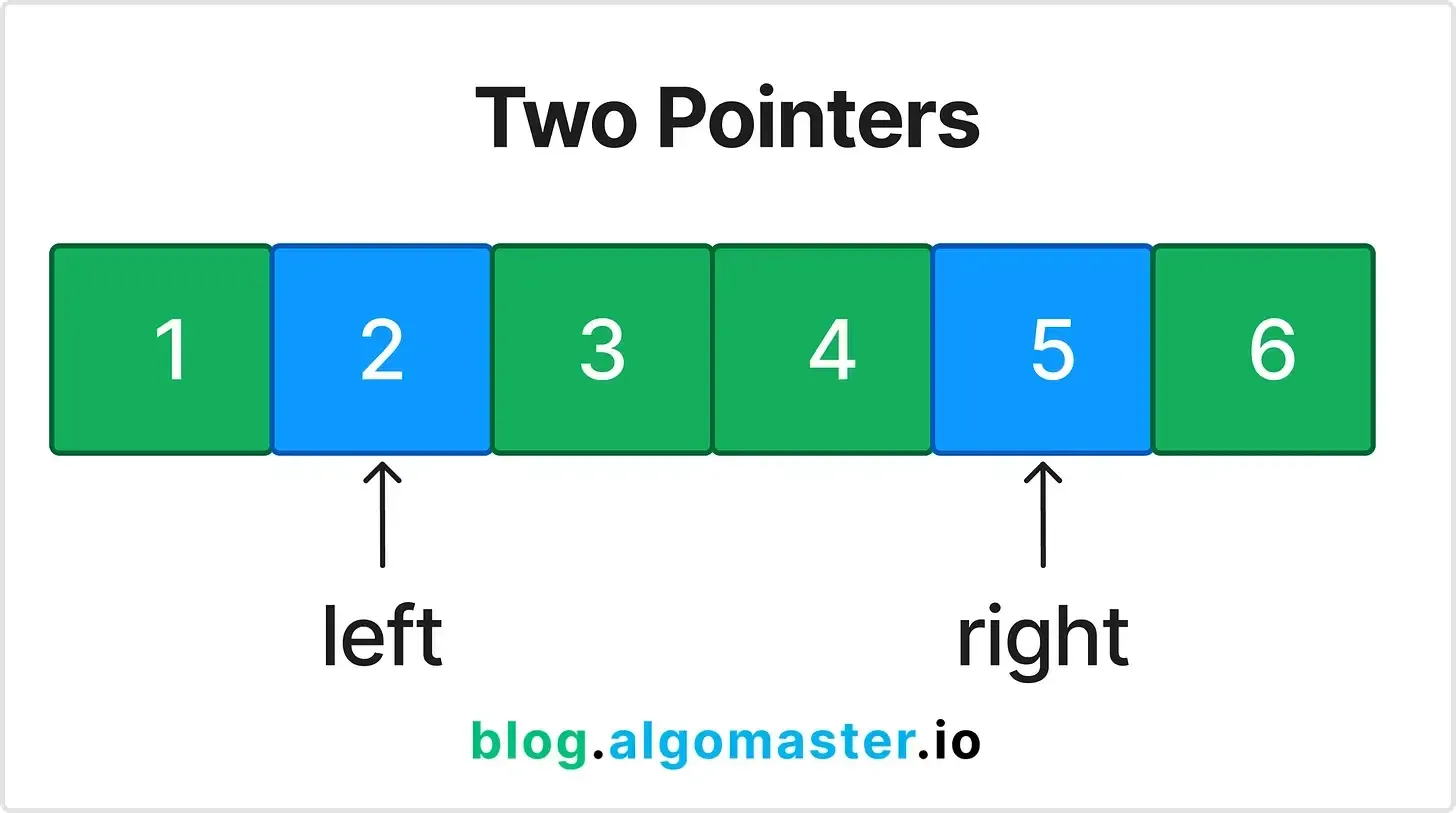

The Two Pointers pattern involves using two pointers to iterate through an array or list, often used to find pairs or elements that meet specific criteria.

Use this pattern when dealing with sorted arrays or lists where you need to find pairs that satisfy a specific condition.

Q. Given a 1-indexed array of integers numbers that is already sorted in non-decreasing order, find two numbers such that they add up to a specific target number. Let these two numbers be numbers[index1] and numbers[index2] where 1 <= index1 < index2 <= numbers.length.

Return the indices of the two numbers, index1 and index2, added by one as an integer array [index1, index2] of length 2.

The tests are generated such that there is exactly one solution. You may not use the same element twice.

Your solution must use only constant extra space.

 

Example 1:

Input: numbers = [2,7,11,15], target = 9
Output: [1,2]
Explanation: The sum of 2 and 7 is 9. Therefore, index1 = 1, index2 = 2. We return [1, 2].
Example 2:

Input: numbers = [2,3,4], target = 6
Output: [1,3]
Explanation: The sum of 2 and 4 is 6. Therefore index1 = 1, index2 = 3. We return [1, 3].
Example 3:

Input: numbers = [-1,0], target = -1
Output: [1,2]
Explanation: The sum of -1 and 0 is -1. Therefore index1 = 1, index2 = 2. We return [1, 2]

https://leetcode.com/problems/two-sum-ii-input-array-is-sorted/description/

In [ ]:
class Solution:
    def twoSum(self, numbers: List[int], target: int) -> List[int]:
        left = 0
        right = len(numbers) - 1

        # while True:
        for _ in range(len(numbers)):
            if left >= right:
                return []
            
            if numbers[left] + numbers[right] == target:
                return [left + 1, right + 1]
            elif numbers[left] + numbers[right] > target:
                right -= 1
            else:
                left += 1
        return []

Q. Given an integer array nums, return all the triplets [nums[i], nums[j], nums[k]] such that i != j, i != k, and j != k, and nums[i] + nums[j] + nums[k] == 0.

Notice that the solution set must not contain duplicate triplets.

 

Example 1:

Input: nums = [-1,0,1,2,-1,-4]
Output: [[-1,-1,2],[-1,0,1]]
Explanation: 
nums[0] + nums[1] + nums[2] = (-1) + 0 + 1 = 0.
nums[1] + nums[2] + nums[4] = 0 + 1 + (-1) = 0.
nums[0] + nums[3] + nums[4] = (-1) + 2 + (-1) = 0.
The distinct triplets are [-1,0,1] and [-1,-1,2].
Notice that the order of the output and the order of the triplets does not matter.
Example 2:

Input: nums = [0,1,1]
Output: []
Explanation: The only possible triplet does not sum up to 0.
Example 3:

Input: nums = [0,0,0]
Output: [[0,0,0]]
Explanation: The only possible triplet sums up to 0.
 

Constraints:

3 <= nums.length <= 3000
-105 <= nums[i] <= 105
 

https://leetcode.com/problems/3sum/description/

In [ ]:
class Solution:
    # Inefficient way
    def threeSum1(self, nums: List[int]) -> List[List[int]]:
        l = len(nums)
        i = 0
        j = l // 3
        k = (l // 3) * 2
        res = []
        ele_str_map = {}
        
        for i in range(0, l - 2):
            for j in range(i + 1, l - 1):
                for k in range(j + 1, l):
                    if nums[i] + nums[j] + nums[k] == 0:
                        ele = sorted([nums[i], nums[j], nums[k]])
                        ele_str = "".join([str(x) for x in ele])
                        if ele_str not in ele_str_map:
                            res.append(ele)
                            ele_str_map[ele_str] = True

        return res

    # Efficient way
    def threeSum(self, nums: List[int]) -> List[List[int]]:
        l = len(nums)
        i = 0
        j = l // 3
        k = (l // 3) * 2
        res = []
        ele_str_map = {}

        nums = sorted(nums)

        if not (nums[0] <= 0 and nums[-1] >= 0):
            return res
        elif nums[0] == nums[-1] == 0:
            return [[0, 0, 0]]
        
        for i in range(0, l - 2):
            j = i + 1
            k = l - 1
            # while True:
            for _ in range(l):
                if j >= k:
                    break

                ijk_sum =nums[i] + nums[j] + nums[k]
                if ijk_sum == 0:
                    ele = sorted([nums[i], nums[j], nums[k]])
                    ele_str = "".join([str(x) for x in ele])
                    if ele_str not in ele_str_map:
                        res.append(ele)
                        ele_str_map[ele_str] = True
                    # break
                    j += 1

                if ijk_sum < 0:
                    j += 1
                else:
                    k -= 1         
            
        return res

Q. You are given an integer array height of length n. There are n vertical lines drawn such that the two endpoints of the ith line are (i, 0) and (i, height[i]).

Find two lines that together with the x-axis form a container, such that the container contains the most water.

Return the maximum amount of water a container can store.

Notice that you may not slant the container.

 

Example 1:

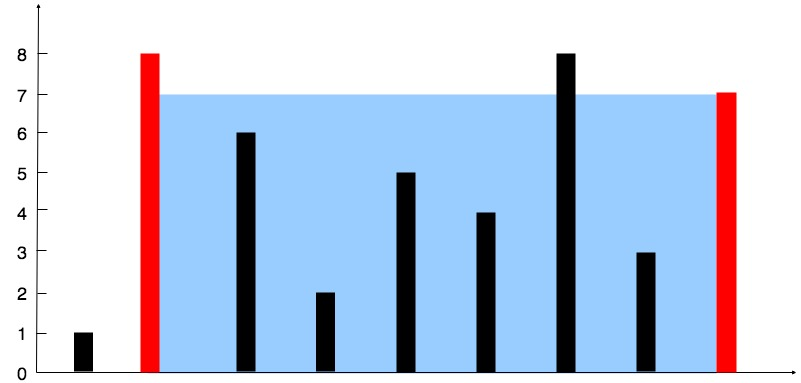


Input: height = [1,8,6,2,5,4,8,3,7]
Output: 49
Explanation: The above vertical lines are represented by array [1,8,6,2,5,4,8,3,7]. In this case, the max area of water (blue section) the container can contain is 49.
Example 2:

Input: height = [1,1]
Output: 1
 

Constraints:

n == height.length
2 <= n <= 105
0 <= height[i] <= 104

In [ ]:
class Solution:
    def maxArea(self, height: List[int]) -> int:
        n = len(height)
        left = 0
        right = (n - 1)
        max_vol = 0
        
        for _ in range(n):
            if left >= right:
                break

            vol = (right - left) * min(height[left], height[right])

            if vol > max_vol:
                max_vol = vol

            if height[left] < height[right]:
                left += 1
            else:
                right -= 1
        
        return max_vol

        

## Sliding Window

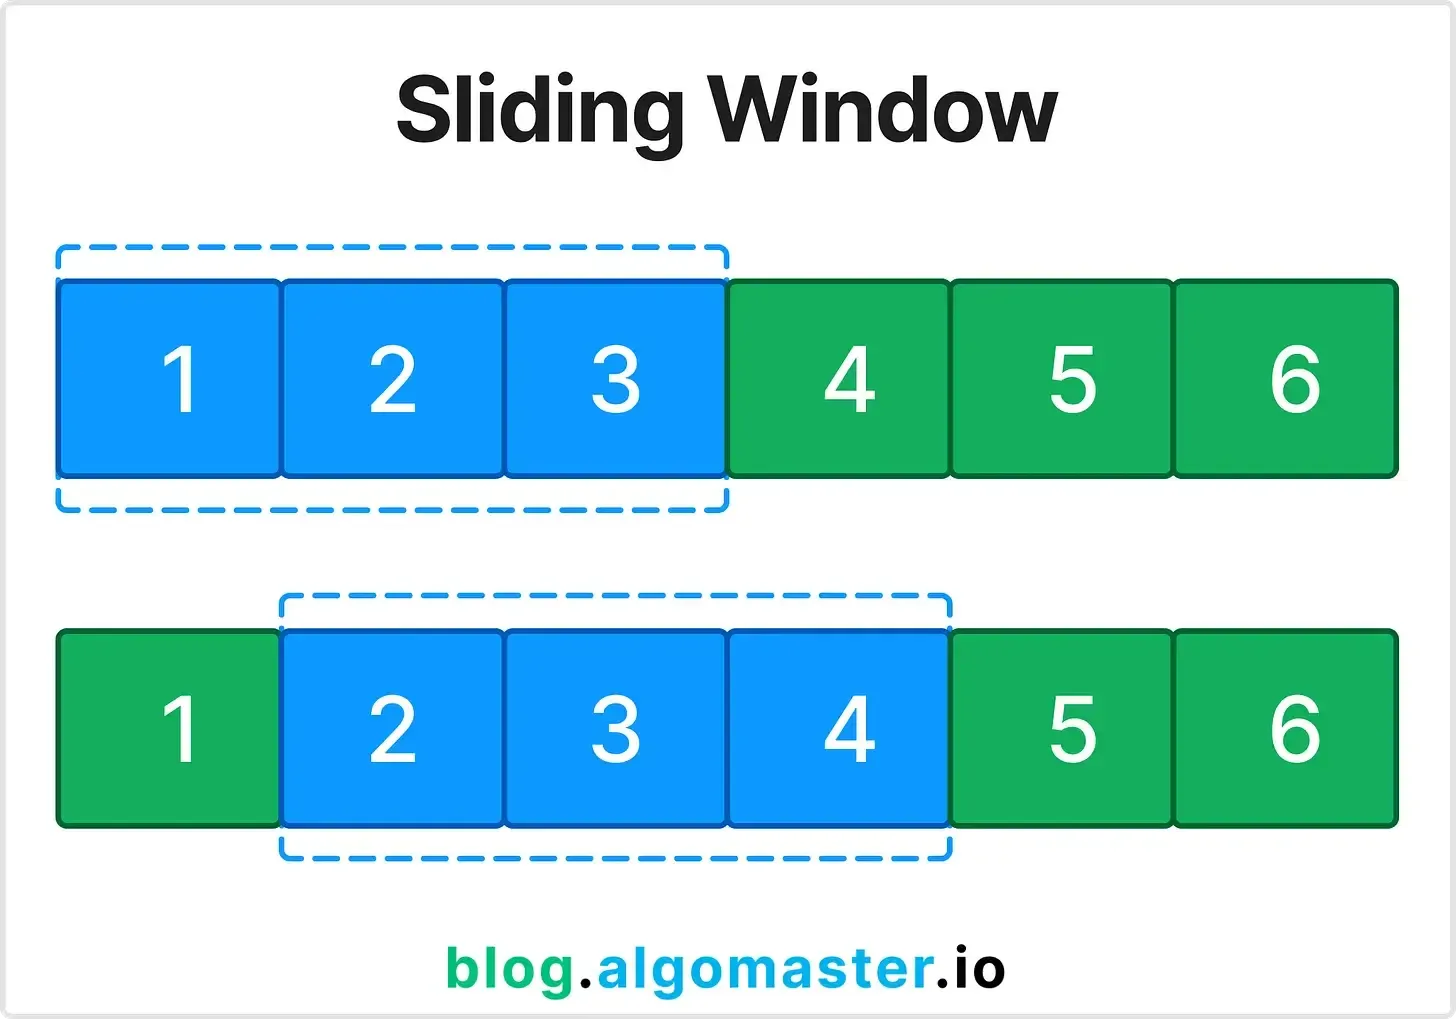

The Sliding Window pattern is used to find a subarray or substring that satisfies a specific condition, optimizing the time complexity by maintaining a window of elements.

Use this pattern when dealing with problems involving contiguous subarrays or substrings.

Sample Problem:
Find the maximum sum of a subarray of size k.

Example:

Input: nums = [2, 1, 5, 1, 3, 2], k = 3

Output: 9

Explanation:
Start with the sum of the first k elements.

Slide the window one element at a time, subtracting the element that goes out of the window and adding the new element.

Keep track of the maximum sum encountered.